In [1]:
from calendar import prweek

import pandas as pd
import numpy as np

In [2]:
patient_info = pd.read_csv('/home/simon/Data/Augsburg_large/patient_info.csv', index_col=[0])
# results = pd.read_excel('/home/simon/Data/Augsburg_large/results.xlsx', index_col=[0, 1])
results = pd.read_excel('/home/simon/Data/Augsburg_large/results_.xlsx', index_col=[0, 1])

# Data exploration

In [3]:
patient_info.head()

,Age,Sex
Patient,,
PA000291,16.0,F
PA000464,13.0,F
PA000654,13.0,F
PA000926,9.0,M
PA000154,15.0,M


In [4]:
patient_info['Age'].describe()

count    951.000000
mean      15.766562
std        7.416353
min        6.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       64.000000
Name: Age, dtype: float64

In [5]:
patient_info['Sex'].value_counts()

Sex
M    490
F    460
O      1
Name: count, dtype: int64

In [6]:
results.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    111.994491       136.696925  11.274674    21.912546   
         left     138.908606       125.093870  11.335815    47.489553   
PA000464 right           NaN              NaN        NaN   168.133151   
         left     100.416752       128.232275        NaN    86.554914   
PA000654 right     99.638389       106.813245  -9.804510    -0.640150   

                       TT        KRA          LL  
Patient  Side                                     
PA000291 right  31.999392   3.918749  850.317034  
         left   35.522329   8.983078  848.194336  
PA000464 right  45.870811  11.592175  874.822478  
         left   42.458543  10.240045  881.223012  
PA000654 right  34.231580   5.453919  781.201966

In [7]:
results.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,LL
count,1773.000000,1773.000000,1648.000000,1780.000000,1599.000000,1603.000000,1900.000000
mean,118.777783,131.454717,6.425617,25.151857,36.186824,32.328358,823.700592
std,19.549981,21.476541,14.193615,19.085909,12.509850,62.092057,85.692164
min,90.028272,90.057497,-47.851110,-51.054192,-85.468897,0.000000,468.370411
25%,102.919003,115.441666,-3.629870,13.453792,29.867387,2.581548,773.161540
50%,116.026178,133.554991,6.056863,24.355694,36.774429,5.548466,829.521254
75%,130.745609,144.216063,16.285286,35.908987,43.545397,10.591867,879.428841
max,177.385424,179.947142,70.607623,184.984395,105.512610,179.831359,1062.607773


In [8]:
# results_.head()

In [9]:
# results_.describe()

In [10]:
combined = results.join(patient_info)

In [11]:
combined.head()

CCD (actual)  CCD (projected)   AT (Lee)  AT (Murphy)  \
Patient  Side                                                           
PA000291 right    111.994491       136.696925  11.274674    21.912546   
         left     138.908606       125.093870  11.335815    47.489553   
PA000464 right           NaN              NaN        NaN   168.133151   
         left     100.416752       128.232275        NaN    86.554914   
PA000654 right     99.638389       106.813245  -9.804510    -0.640150   

                       TT        KRA          LL   Age Sex  
Patient  Side                                               
PA000291 right  31.999392   3.918749  850.317034  16.0   F  
         left   35.522329   8.983078  848.194336  16.0   F  
PA000464 right  45.870811  11.592175  874.822478  13.0   F  
         left   42.458543  10.240045  881.223012  13.0   F  
PA000654 right  34.231580   5.453919  781.201966  13.0   F

In [12]:
combined.describe()

,CCD (actual),CCD (projected),AT (Lee),AT (Murphy),TT,KRA,LL,Age
count,1773.000000,1773.000000,1648.000000,1780.000000,1599.000000,1603.000000,1900.000000,1902.000000
mean,118.777783,131.454717,6.425617,25.151857,36.186824,32.328358,823.700592,15.766562
std,19.549981,21.476541,14.193615,19.085909,12.509850,62.092057,85.692164,7.414402
min,90.028272,90.057497,-47.851110,-51.054192,-85.468897,0.000000,468.370411,6.000000
25%,102.919003,115.441666,-3.629870,13.453792,29.867387,2.581548,773.161540,12.000000
50%,116.026178,133.554991,6.056863,24.355694,36.774429,5.548466,829.521254,14.000000
75%,130.745609,144.216063,16.285286,35.908987,43.545397,10.591867,879.428841,16.000000
max,177.385424,179.947142,70.607623,184.984395,105.512610,179.831359,1062.607773,64.000000


In [13]:
combined['Sex'].value_counts()

Sex
M    980
F    920
O      2
Name: count, dtype: int64

Remove 'other'...

In [14]:
from matplotlib import pyplot as plt

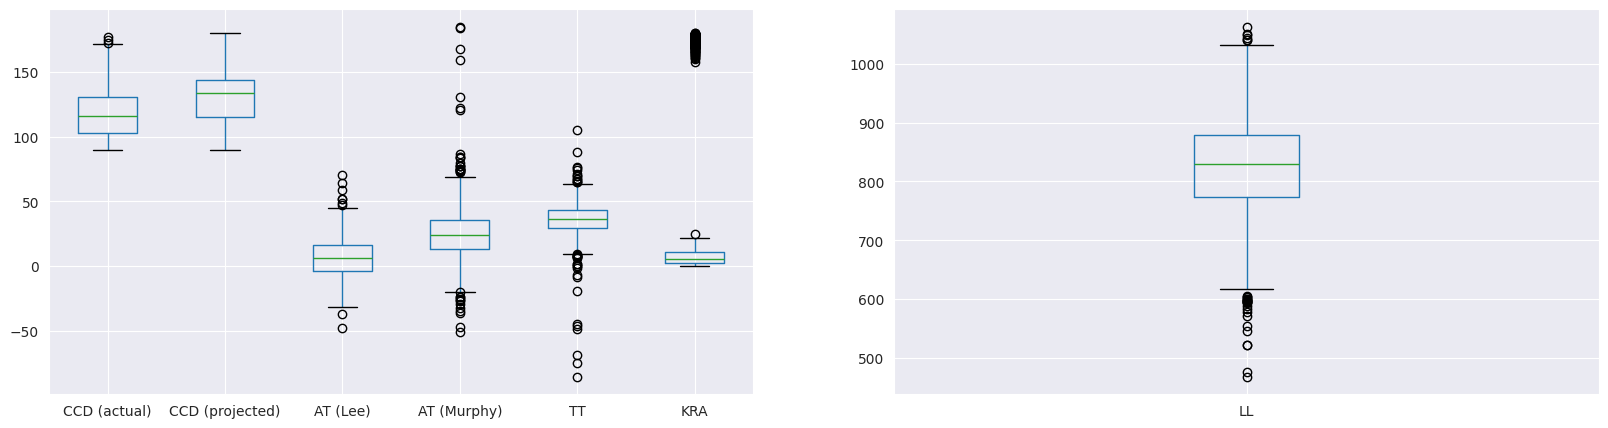

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
ax[0] = combined.boxplot(column=['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA'], ax=ax[0])
ax[1] = combined.boxplot(column=['LL'], ax=ax[1])
plt.show()


Remove all KRA > 100...

In [16]:
segm_hip = pd.read_csv('/home/simon/Data/Augsburg_large/proxy_metrics_hip.csv')
segm_hip.describe()

,asd,hd,dice
count,72.000000,72.000000,72.000000
mean,0.938271,8.093738,0.910803
std,1.144623,21.536580,0.019931
min,0.290118,1.546796,0.847302
25%,0.559658,2.445699,0.897708
50%,0.652040,3.281250,0.916046
75%,0.775575,4.375000,0.923821
max,7.496712,130.377494,0.943607


In [17]:
segm_hip.head()

,Unnamed: 0,asd,hd,dice
0,t1_tse_tra_Huften_bds_PA000365.nii.gz,0.563986,2.445699,0.912012
1,t1_tse_tra_Huften_bds_PA000452.nii.gz,0.650587,3.943572,0.922444
2,t1_tse_tra_Huften_bds_PA000422.nii.gz,0.701714,3.093592,0.891976
3,t1_tse_tra_Huften_bds_PA000359.nii.gz,0.370469,2.187500,0.940678
4,t1_tse_tra_Huften_bds_PA000371.nii.gz,0.716598,3.281250,0.916953


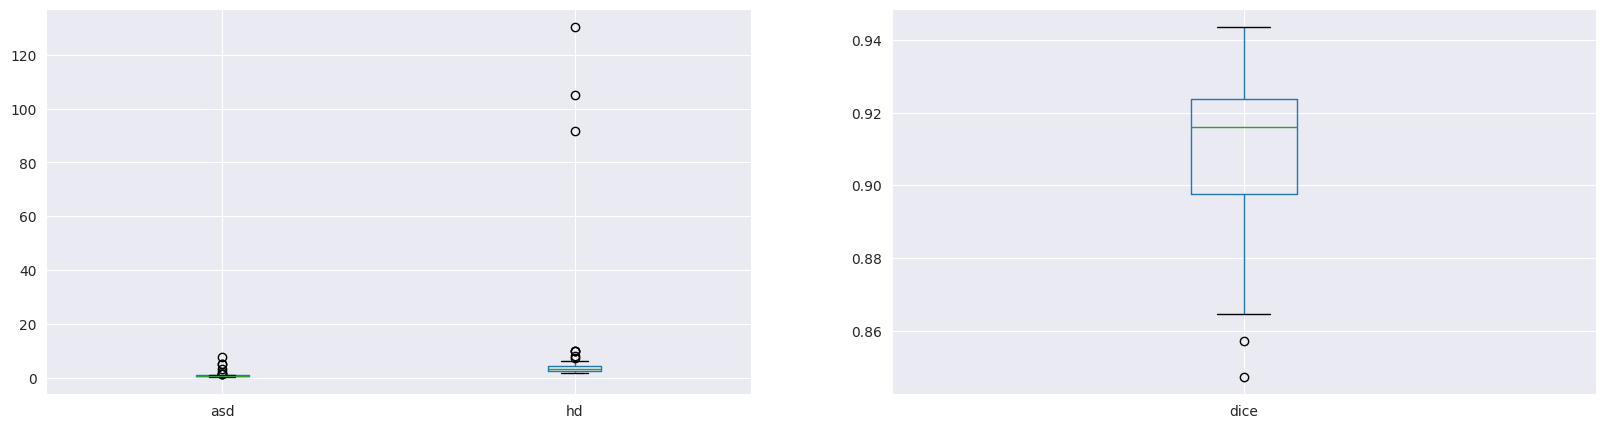

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
ax[0] = segm_hip.boxplot(column=['asd', 'hd'], ax=ax[0])
ax[1] = segm_hip.boxplot(column=['dice'], ax=ax[1])
plt.show()

In [19]:
segm_knee = pd.read_csv('/home/simon/Data/Augsburg_large/proxy_metrics_knee.csv')
segm_knee.describe()

,asd,hd,dice
count,65.000000,66.000000,66.000000
mean,0.446045,2.414985,0.931861
std,0.154632,1.089407,0.117254
min,0.118801,0.000000,0.000000
25%,0.361578,2.187500,0.938693
50%,0.436486,2.316600,0.946240
75%,0.519034,2.445699,0.956355
max,1.010373,8.577314,0.975442


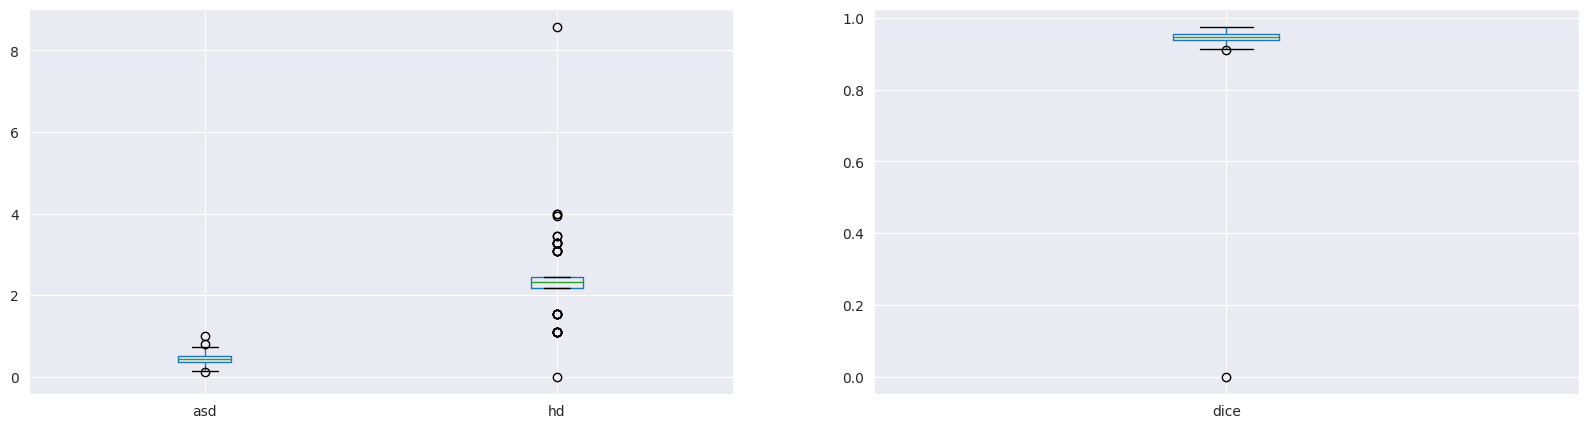

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
ax[0] = segm_knee.boxplot(column=['asd', 'hd'], ax=ax[0])
ax[1] = segm_knee.boxplot(column=['dice'], ax=ax[1])
plt.show()

In [21]:
segm_ankle = pd.read_csv('/home/simon/Data/Augsburg_large/proxy_metrics_ankle.csv')
segm_ankle.describe()

,asd,hd,dice
count,83.000000,88.000000,87.000000
mean,0.639918,3.400315,0.861766
std,1.552034,7.589259,0.229674
min,0.048347,0.000000,0.000000
25%,0.278483,1.093750,0.913740
50%,0.347323,1.546796,0.928705
75%,0.448910,3.093592,0.940829
max,12.593968,50.502359,0.975976


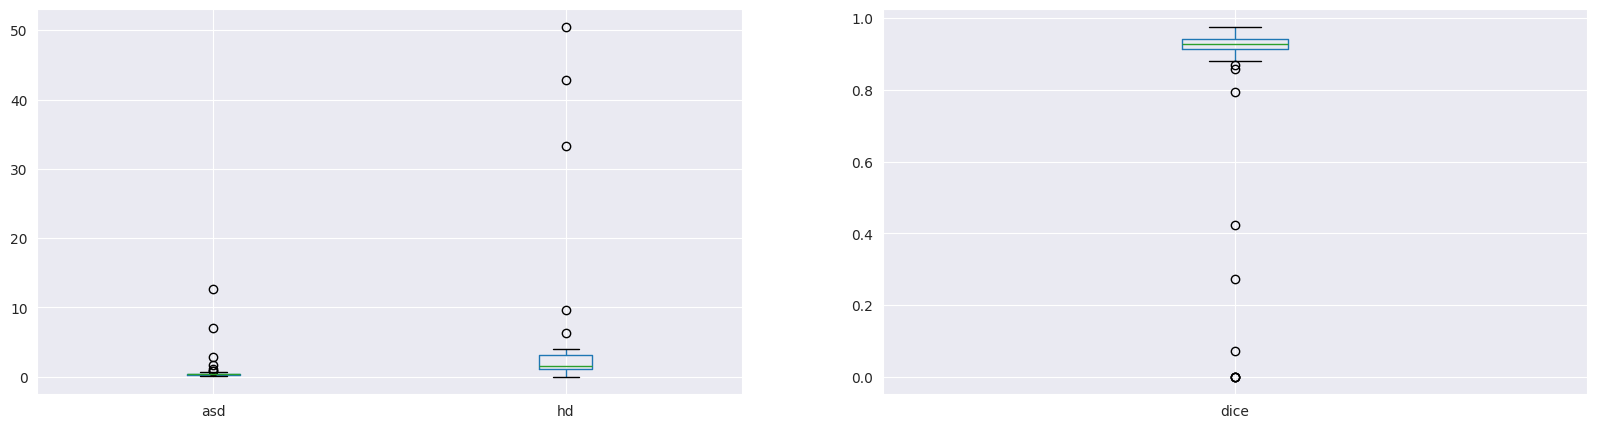

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
ax[0] = segm_ankle.boxplot(column=['asd', 'hd'], ax=ax[0])
ax[1] = segm_ankle.boxplot(column=['dice'], ax=ax[1])
plt.show()

# Data preprocessing

#Rows (raw):

In [23]:
combined.shape[0], combined.shape[0] / 2

(1908, 954.0)

In [24]:
combined.drop(combined[combined['Sex'] == 'O'].index, inplace=True)

#Rows after dropping sex = 'other'

In [25]:
combined.shape[0], combined.shape[0] / 2

(1906, 953.0)

In [26]:
total_before = combined.shape[0]

Non-empty cells (absolute #), per factor

In [27]:
counts_before = combined.describe().loc['count']
counts_before

CCD (actual)       1771.0
CCD (projected)    1771.0
AT (Lee)           1646.0
AT (Murphy)        1778.0
TT                 1597.0
KRA                1601.0
LL                 1898.0
Age                1900.0
Name: count, dtype: float64

Non-empty cells (percentage), per factor

In [28]:
counts_before.apply(lambda x: x / total_before)

CCD (actual)       0.929171
CCD (projected)    0.929171
AT (Lee)           0.863589
AT (Murphy)        0.932844
TT                 0.837880
KRA                0.839979
LL                 0.995803
Age                0.996852
Name: count, dtype: float64

## Outlier removal

In [29]:
def set_outliers_to_nan(column):
    mean = column.mean()
    std = column.std()
    return column.apply(lambda x: np.nan if abs(x - mean) > 2 * std else x)

In [30]:
combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']] = combined[['CCD (actual)', 'CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'TT', 'KRA']].apply(set_outliers_to_nan)  # exclude leg length because it seems robust to outliers

In [31]:
combined['KRA'] = combined['KRA'].apply(lambda x: np.nan if x > 100 else x)

Non-empty cells after outlier removal (absolute #), per factor

In [32]:
counts_after = combined.describe().loc['count']
counts_after

CCD (actual)       1683.0
CCD (projected)    1737.0
AT (Lee)           1583.0
AT (Murphy)        1715.0
TT                 1548.0
KRA                1345.0
LL                 1898.0
Age                1900.0
Name: count, dtype: float64

In [33]:
counts_before - counts_after

CCD (actual)        88.0
CCD (projected)     34.0
AT (Lee)            63.0
AT (Murphy)         63.0
TT                  49.0
KRA                256.0
LL                   0.0
Age                  0.0
Name: count, dtype: float64

Non-empty cells after outlier removal (percentage), per factor

In [34]:
counts_after.apply(lambda x: x / total_before)

CCD (actual)       0.883001
CCD (projected)    0.911333
AT (Lee)           0.830535
AT (Murphy)        0.899790
TT                 0.812172
KRA                0.705666
LL                 0.995803
Age                0.996852
Name: count, dtype: float64

In [35]:
(counts_before - counts_after).apply(lambda x: x / total_before)

CCD (actual)       0.046170
CCD (projected)    0.017838
AT (Lee)           0.033054
AT (Murphy)        0.033054
TT                 0.025708
KRA                0.134313
LL                 0.000000
Age                0.000000
Name: count, dtype: float64

# AT as function of age

In [36]:
from sklearn import linear_model

In [37]:
X = combined[['AT (Lee)', 'AT (Murphy)', 'Age']].copy()
X = X.dropna()
Y_1 = X['AT (Lee)']
Y_2 = X['AT (Murphy)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [38]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([-0.01919925])

In [39]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.18885464])

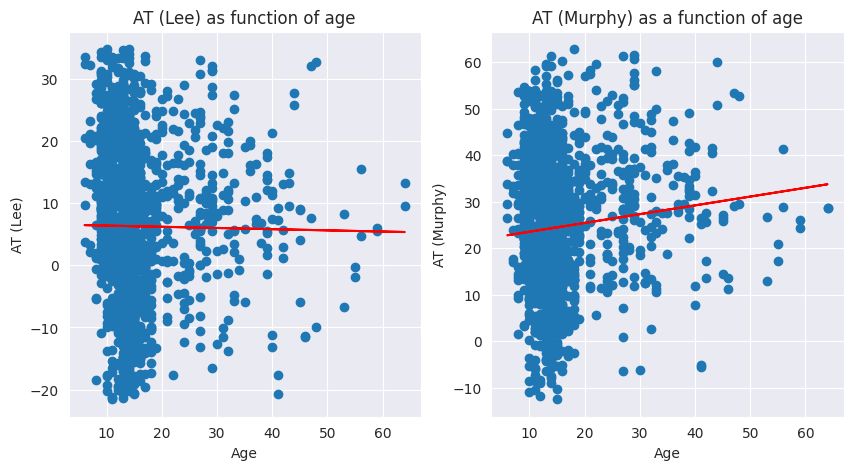

In [40]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='AT (Lee) as function of age', xlabel='Age', ylabel='AT (Lee)')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='AT (Murphy) as a function of age', xlabel='Age', ylabel='AT (Murphy)')
plt.show()

# AT as function of sex

In [41]:
data = combined[['AT (Lee)', 'AT (Murphy)', 'Sex']].copy()
data = data.dropna()

In [42]:
import seaborn as sns

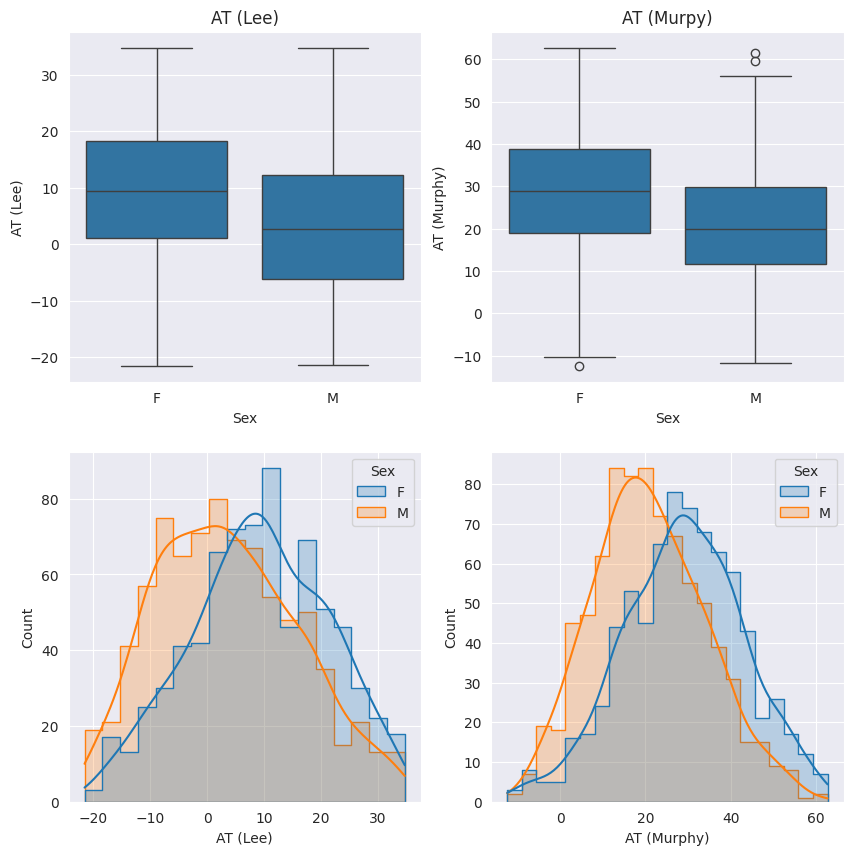

In [43]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='AT (Lee)', data=data, ax=ax[0, 0])
ax[0][0].set(title='AT (Lee)')
sns.boxplot(x='Sex', y='AT (Murphy)', data=data, ax=ax[0, 1])
ax[0][1].set(title='AT (Murpy)')
sns.histplot(x='AT (Lee)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='AT (Murphy)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()


In [44]:
from scipy import stats

In [45]:
from sklearn.preprocessing import LabelBinarizer

In [46]:
lb = LabelBinarizer()
lb.fit(data['Sex'])

LabelBinarizer()

In [47]:
labels = lb.transform(data['Sex'])

In [48]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000654 right   F      0
         left    F      0
PA000926 right   M      1
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1566 rows x 2 columns]

In [49]:
stats.pointbiserialr(labels.T[0], data['AT (Lee)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.22328412753183763, pvalue=3.82090446052042e-19)

In [50]:
stats.pointbiserialr(labels.T[0], data['AT (Murphy)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.28040243379868024, pvalue=1.1037468196407382e-29)

**Interpretation:** Male is encoded 1 and Female is encoded 0, so a negative correlation means that the AT is higher for females

## Normality testing

In [51]:
at_lee_male, at_lee_female = data[data['Sex'] == 'M']['AT (Lee)'], data[data['Sex'] == 'F']['AT (Lee)']
at_murphy_male, at_murphy_female = data[data['Sex'] == 'M']['AT (Murphy)'], data[data['Sex'] == 'F']['AT (Murphy)']

In [52]:
stats.shapiro(at_lee_male.to_numpy())

ShapiroResult(statistic=0.9838072096556372, pvalue=7.78980600070041e-08)

In [53]:
stats.shapiro(at_lee_female.to_numpy())

ShapiroResult(statistic=0.9910397334127196, pvalue=0.0001568481872231214)

In [54]:
stats.shapiro(at_murphy_male.to_numpy())

ShapiroResult(statistic=0.9935016438600875, pvalue=0.0013333229130656741)

In [55]:
stats.shapiro(at_murphy_female.to_numpy())

ShapiroResult(statistic=0.9957958446493114, pvalue=0.039897610823590966)

**These results are contradictory (?), check q-q plots:**

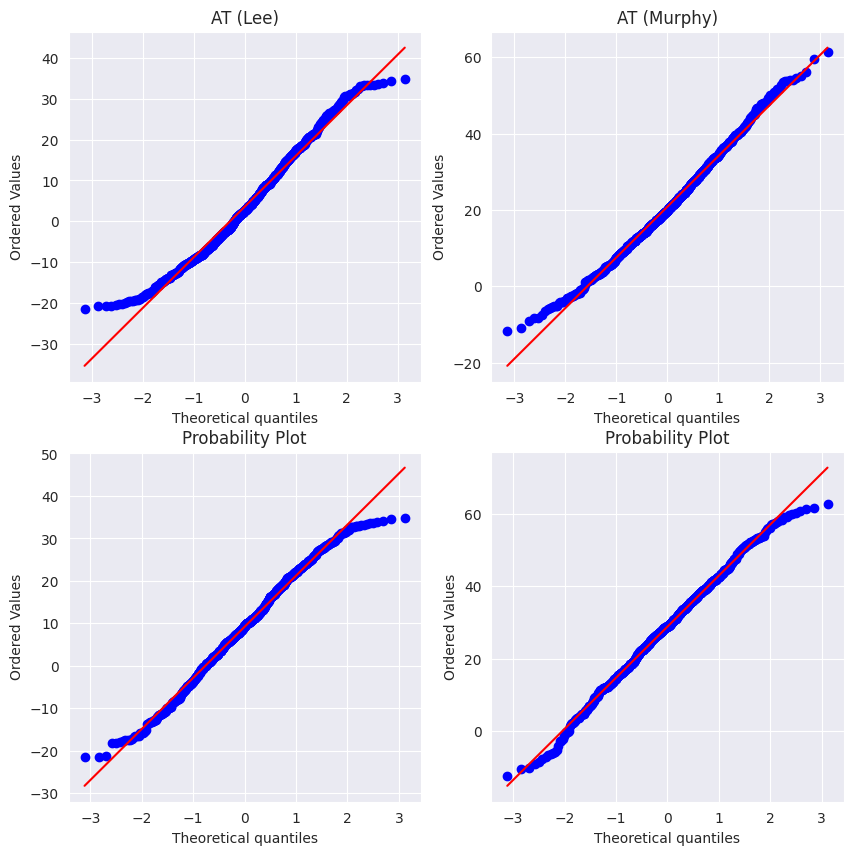

In [56]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(at_lee_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='AT (Lee)')
stats.probplot(at_lee_female.to_numpy(), plot=ax[1, 0])
stats.probplot(at_murphy_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='AT (Murphy)')
stats.probplot(at_murphy_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are normally distributed**

In [57]:
stats.levene(at_lee_male, at_lee_female)

LeveneResult(statistic=1.7198426793754358, pvalue=0.18990578315280932)

In [58]:
stats.levene(at_murphy_male, at_murphy_female)

LeveneResult(statistic=1.6843123029637035, pvalue=0.19454380162548768)

**Can assume both to have equal variance**

In [59]:
stats.ttest_ind(at_lee_male.to_numpy(), at_lee_female.to_numpy(), equal_var=True)

TtestResult(statistic=-9.059025156001878, pvalue=3.8209044605203036e-19, df=1564.0)

In [60]:
stats.ttest_ind(at_murphy_male.to_numpy(), at_murphy_female.to_numpy(), equal_var=True)

TtestResult(statistic=-11.552661935313896, pvalue=1.1037468196407108e-29, df=1564.0)

**-> There is a significant difference between male and female**

## Effect size

In [61]:
import numpy as np

In [62]:
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

In [63]:
cohen_d(at_lee_male.to_numpy(), at_lee_female.to_numpy())

-0.45820119950152693

In [64]:
cohen_d(at_murphy_male.to_numpy(), at_murphy_female.to_numpy())

-0.5843281661150251

**Interpretation:**
- 0.2 < d < 0.5: small effect
- 0.5 < d < 0.8: medium effect
- 0.8 < d: strong effect

# TT as function of age

In [65]:
X = combined[['TT', 'Age']].copy()
X = X.dropna()
Y = X['TT']
X = X['Age'].to_numpy().reshape(-1, 1)

In [66]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([-0.02607729])

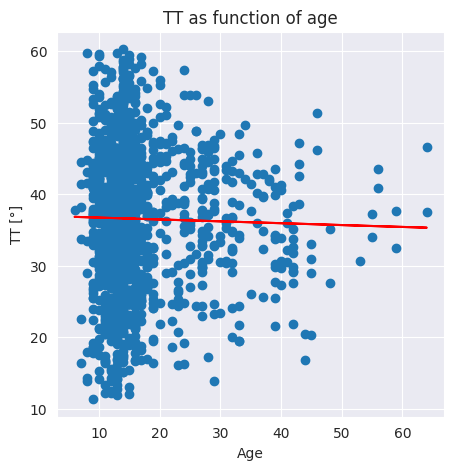

In [67]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='TT as function of age', xlabel='Age', ylabel='TT [°]')
plt.show()

# TT as function of sex

In [68]:
data = combined[['TT', 'Sex']].copy()
data = data.dropna()

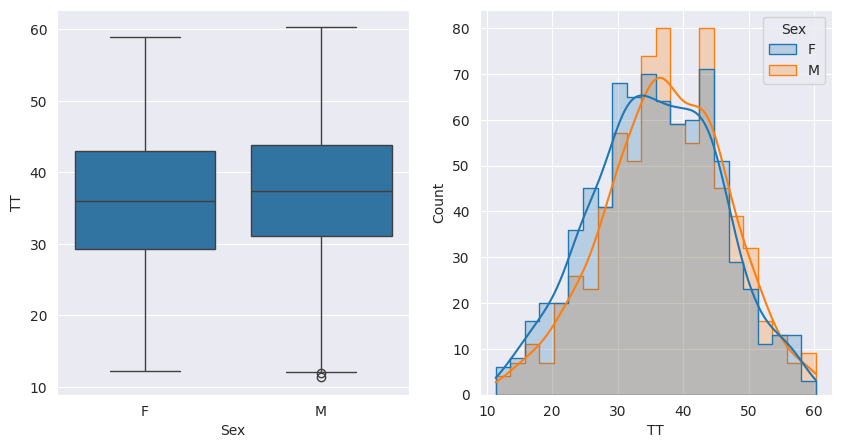

In [69]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='TT', data=data, ax=ax[0])
sns.histplot(x='TT', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [70]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [71]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1548 rows x 2 columns]

In [72]:
stats.pointbiserialr(labels.T[0], data['TT'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.0800847601006172, pvalue=0.0016136613031556498)

**Interpretation:** Positive coefficient means TT is higher for males (encoded as 1)

## Normality testing

In [73]:
tt_male, tt_female = data[data['Sex'] == 'M']['TT'], data[data['Sex'] == 'F']['TT']

In [74]:
stats.shapiro(tt_male.to_numpy())

ShapiroResult(statistic=0.995976764746338, pvalue=0.04882095667272519)

In [75]:
stats.shapiro(tt_female.to_numpy())

ShapiroResult(statistic=0.9945049914241049, pvalue=0.005737287218556208)

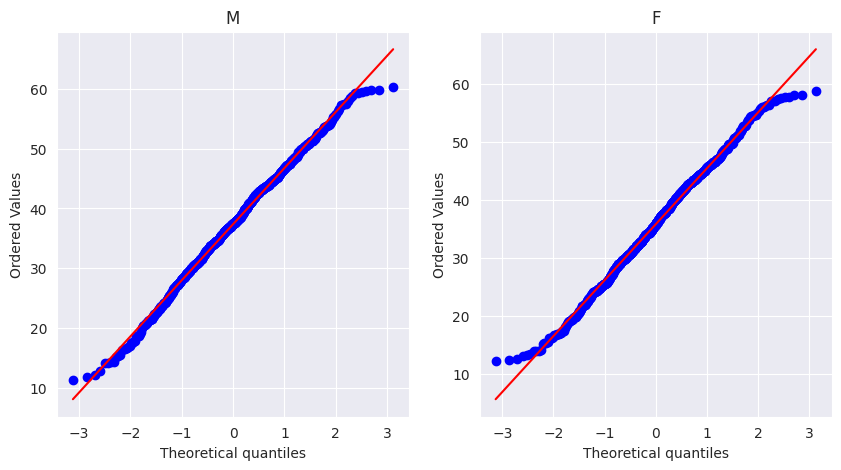

In [76]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(tt_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(tt_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are normally distributed**

In [77]:
stats.levene(tt_male, at_lee_female)

LeveneResult(statistic=47.832814367941545, pvalue=6.838041340512168e-12)

In [78]:
stats.levene(tt_female, at_murphy_female)

LeveneResult(statistic=83.57038833743808, pvalue=1.883027589974647e-19)

**Can assume both to not have equal variance**

In [79]:
stats.ttest_ind(tt_male.to_numpy(), tt_female.to_numpy(), equal_var=False)

TtestResult(statistic=3.1612475377593077, pvalue=0.0016014354738992085, df=1545.5947062198488)

**-> There is a significant difference between male and female**

## Effect size

In [80]:
cohen_d(tt_male.to_numpy(), tt_female.to_numpy())

0.16062523918790017

**Interpretation:**
- 0.2 < d < 0.5: small
effect
- 0.5 < d < 0.8: medium
effect
- 0.8 < d: strong
effect

# CCD as function of age

In [81]:
X = combined[['CCD (actual)', 'CCD (projected)', 'Age']].copy()
X = X.dropna()
Y_1 = X['CCD (actual)']
Y_2 = X['CCD (projected)']
X = X['Age'].to_numpy().reshape(-1, 1)

In [82]:
reg_1 = linear_model.LinearRegression()
reg_1.fit(X, Y_1)
reg_1.coef_

array([0.30784175])

In [83]:
stats.pearsonr(X.flatten(), Y_1)

PearsonRResult(statistic=0.1343978855942443, pvalue=3.8714898921905253e-08)

In [84]:
reg_2 = linear_model.LinearRegression()
reg_2.fit(X, Y_2)
reg_2.coef_

array([0.03529546])

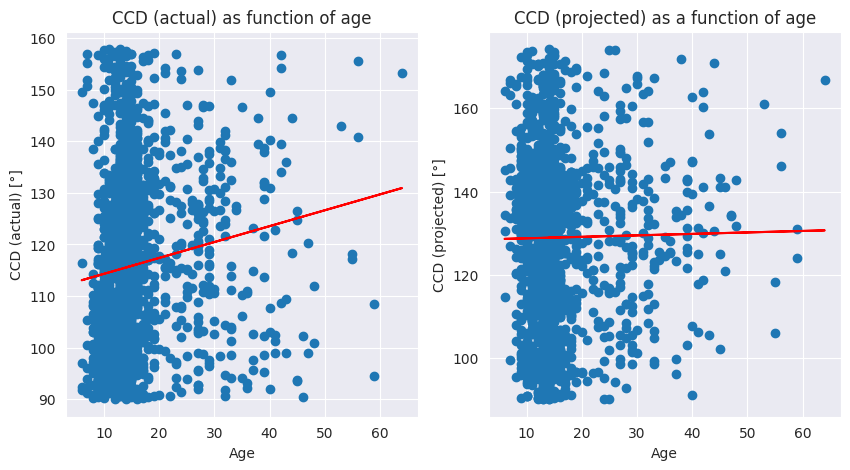

In [85]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=False)
ax[0].scatter(X, Y_1)
ax[0].plot(X, reg_1.predict(X), 'r')
ax[0].set(title='CCD (actual) as function of age', xlabel='Age', ylabel='CCD (actual) [°]')
ax[1].scatter(X, Y_2)
ax[1].plot(X, reg_2.predict(X), 'r')
ax[1].set(title='CCD (projected) as a function of age', xlabel='Age', ylabel='CCD (projected) [°]')
plt.show()

# CCD as function of Sex

In [86]:
data = combined[['CCD (actual)', 'CCD (projected)', 'Sex']].copy()
data = data.dropna()

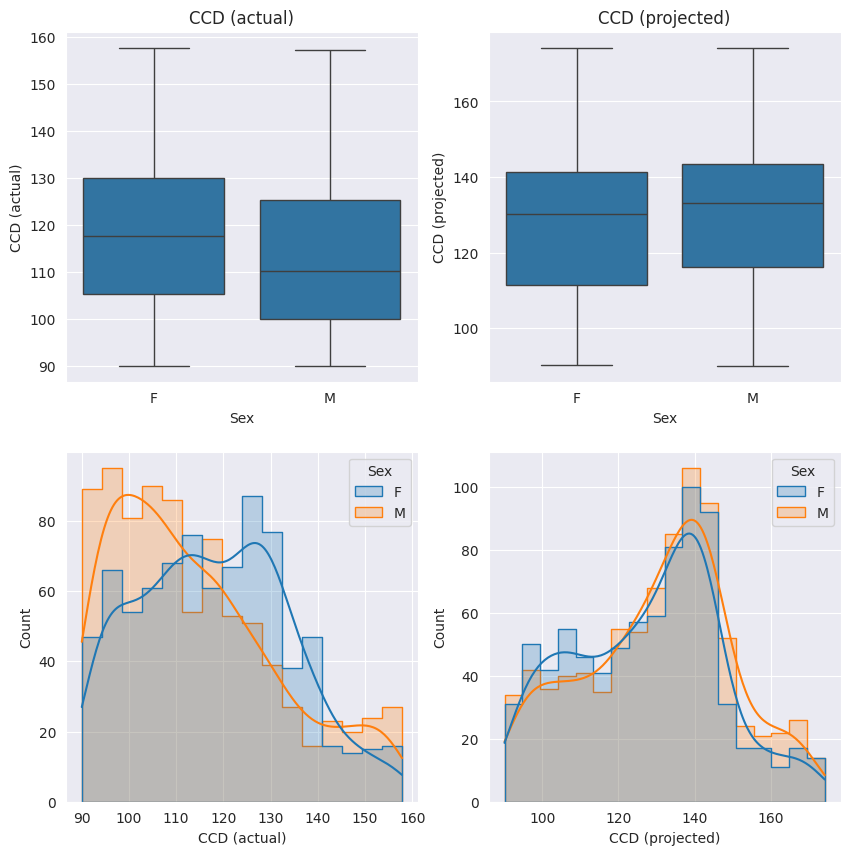

In [87]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
sns.boxplot(x='Sex', y='CCD (actual)', data=data, ax=ax[0, 0])
ax[0][0].set(title='CCD (actual)')
sns.boxplot(x='Sex', y='CCD (projected)', data=data, ax=ax[0, 1])
ax[0][1].set(title='CCD (projected)')
sns.histplot(x='CCD (actual)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 0])
sns.histplot(x='CCD (projected)', hue='Sex', kde=True, element='step', data=data, ax=ax[1, 1])
plt.show()

In [88]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])

In [89]:
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 left    F      0
PA000654 right   F      0
         left    F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1660 rows x 2 columns]

In [90]:
stats.pointbiserialr(labels.T[0], data['CCD (actual)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.114512146233793, pvalue=2.9045184440612853e-06)

**Interpretation:** Negative coefficient means CCD is higher for females (encoded as 0)

In [91]:
stats.pointbiserialr(labels.T[0], data['CCD (projected)'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.07039485243196916, pvalue=0.004111159806486471)

**Interpretation:** Positive coefficient means CCD is higher for males (encoded as 1)

## Normality testing

In [92]:
ccd_actual_male, ccd_actual_female = data[data['Sex'] == 'M']['CCD (actual)'], data[data['Sex'] == 'F']['CCD (actual)']
ccd_projected_male, ccd_projected_female = data[data['Sex'] == 'M']['CCD (projected)'], data[data['Sex'] == 'F']['CCD (projected)']

In [93]:
stats.shapiro(ccd_actual_male.to_numpy())

ShapiroResult(statistic=0.9318212690105324, pvalue=3.1083218830936613e-19)

In [94]:
stats.shapiro(ccd_actual_female.to_numpy())

ShapiroResult(statistic=0.9782658755850364, pvalue=1.2923576152101974e-09)

In [95]:
stats.shapiro(ccd_projected_male.to_numpy())

ShapiroResult(statistic=0.9779557157419073, pvalue=4.958903867843668e-10)

In [96]:
stats.shapiro(ccd_projected_female.to_numpy())

ShapiroResult(statistic=0.975849320358299, pvalue=2.569094266928204e-10)

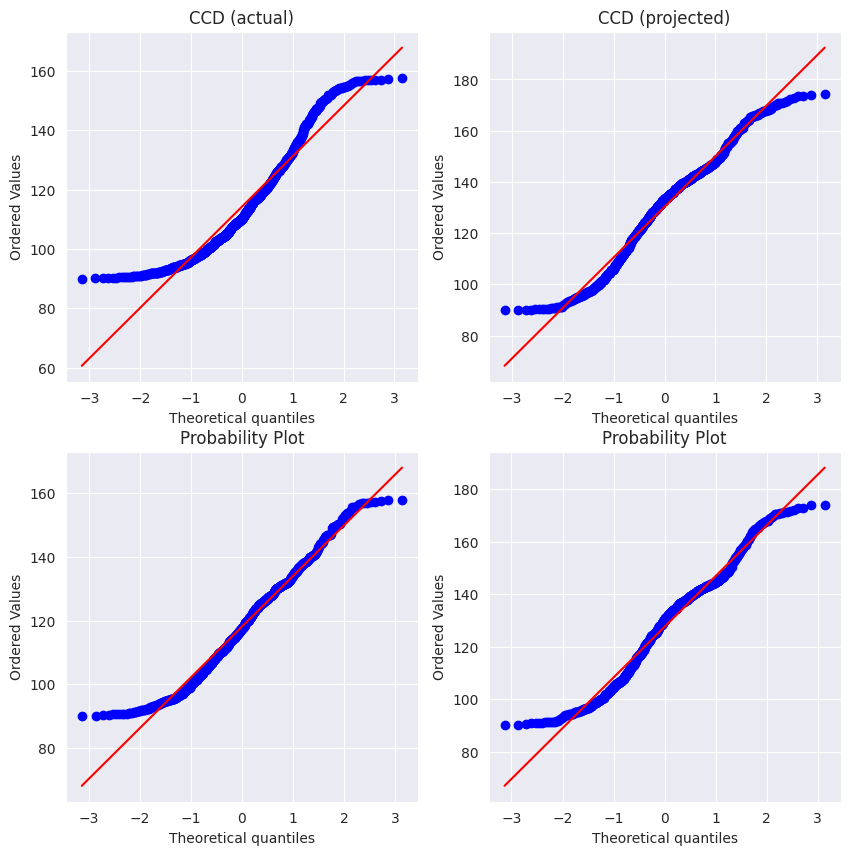

In [97]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
stats.probplot(ccd_actual_male.to_numpy(), plot=ax[0, 0])
ax[0, 0].set(title='CCD (actual)')
stats.probplot(ccd_actual_female.to_numpy(), plot=ax[1, 0])
stats.probplot(ccd_projected_male.to_numpy(), plot=ax[0, 1])
ax[0, 1].set(title='CCD (projected)')
stats.probplot(ccd_projected_female.to_numpy(), plot=ax[1, 1])
plt.show()

**Plots show data are not normally distributed**

In [98]:
stats.mannwhitneyu(ccd_actual_male, ccd_actual_female, alternative='two-sided')

MannwhitneyuResult(statistic=288581.0, pvalue=1.1808056299100367e-08)

In [99]:
stats.mannwhitneyu(ccd_projected_male, ccd_projected_female, alternative='two-sided')

MannwhitneyuResult(statistic=373245.0, pvalue=0.002977135160041517)

**There is a significant difference for both**

## Effect size

In [100]:
%load_ext rpy2.ipython

In [101]:
%%R
library(effectsize)

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/local/lib/R/site-library’ contains no packages


In [102]:
tmp1, tmp2 = ccd_actual_male.to_numpy(), ccd_actual_female.to_numpy()

In [103]:
%%R -i tmp1 -i tmp2
ccd_actual_male <- tmp1
ccd_actual_female <- tmp2

In [104]:
%%R
rb <- rank_biserial(ccd_actual_male, ccd_actual_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |         95% CI | Interpretation
---------------------------------------------------
-0.16             | [-0.22, -0.11] |          small

- Interpretation rule: funder2019

In [105]:
tmp1, tmp2 = ccd_projected_male.to_numpy(), ccd_projected_female.to_numpy()

In [106]:
%%R -i tmp1 -i tmp2
ccd_projected_male <- tmp1
ccd_projected_female <- tmp2


In [107]:
%%R
rb <- rank_biserial(ccd_projected_male, ccd_projected_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |       95% CI | Interpretation
-------------------------------------------------
0.08              | [0.03, 0.14] |     very small

- Interpretation rule: funder2019

# KRA as function of age

In [108]:
X = combined[['KRA', 'Age']].copy()
X = X.dropna()
Y = X['KRA']
X = X['Age'].to_numpy().reshape(-1, 1)

In [109]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([0.03279325])

In [110]:
stats.pearsonr(X.flatten(), Y)

PearsonRResult(statistic=0.06452047167727673, pvalue=0.017956914860569502)

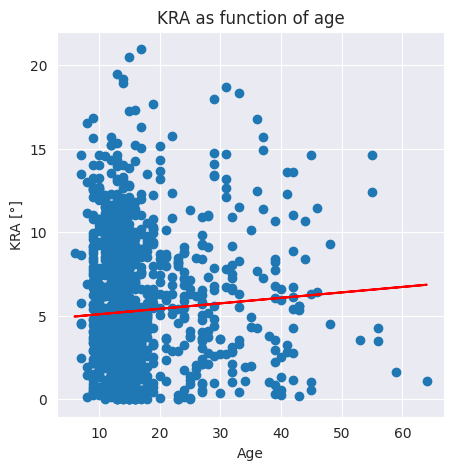

In [111]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='KRA as function of age', xlabel='Age', ylabel='KRA [°]')
plt.show()

# KRA as function of sex

In [112]:
data = combined[['KRA', 'Sex']].copy()
data = data.dropna()

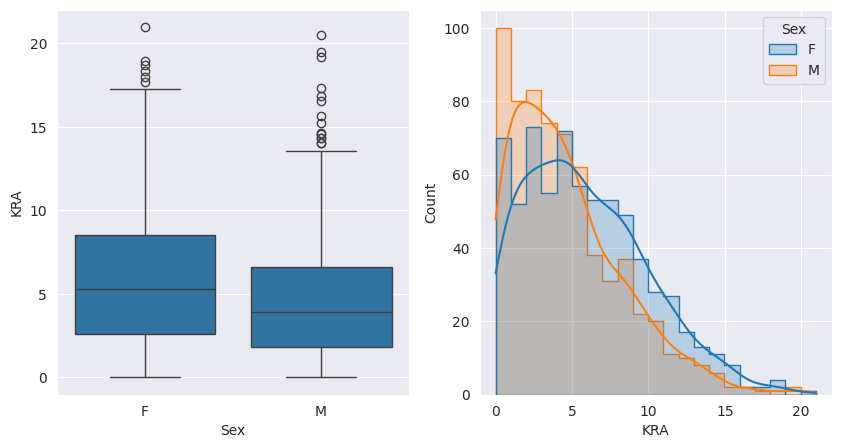

In [113]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='KRA', data=data, ax=ax[0])
sns.histplot(x='KRA', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [114]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA000491 right   F      0
PA001031 right   F      0
PA000807 left    F      0
PA000227 right   M      1
         left    M      1

[1345 rows x 2 columns]

In [115]:
stats.pointbiserialr(labels.T[0], data['KRA'].to_numpy())  # wtf numpy

SignificanceResult(statistic=-0.16213907165809271, pvalue=2.225741721146498e-09)

**Interpretation:** Negative coefficient means TT is higher for females (encoded as 0)

## Normality testing

In [116]:
kra_male, kra_female = data[data['Sex'] == 'M']['KRA'], data[data['Sex'] == 'F']['KRA']

In [117]:
stats.shapiro(kra_male.to_numpy())

ShapiroResult(statistic=0.9177955570985556, pvalue=1.764274778275616e-18)

In [118]:
stats.shapiro(kra_female.to_numpy())

ShapiroResult(statistic=0.9573972674059483, pvalue=3.498777957944249e-13)

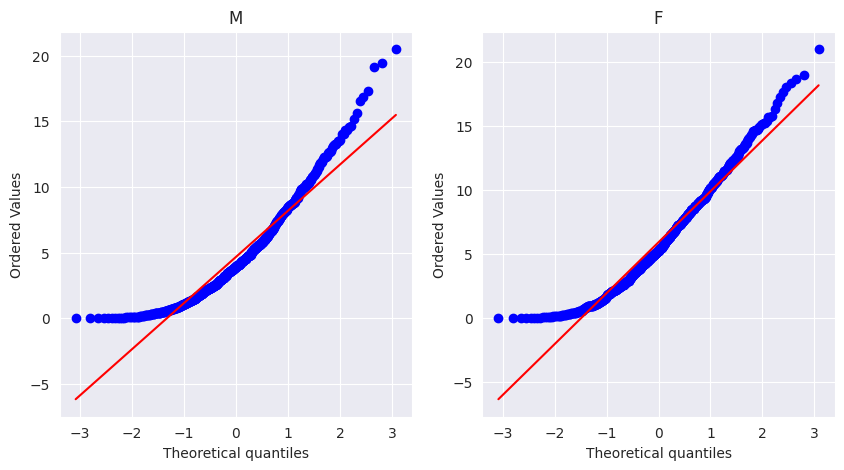

In [119]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(kra_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(kra_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are not normally distributed**

In [120]:
stats.mannwhitneyu(kra_male, kra_female, alternative='two-sided')

MannwhitneyuResult(statistic=182771.5, pvalue=1.2098498029544084e-09)

## Effect size

In [121]:
tmp1, tmp2 = kra_male.to_numpy(), kra_female.to_numpy()

In [122]:
%%R -i tmp1 -i tmp2
kra_male <- tmp1
kra_female <- tmp2

In [123]:
%%R
rb <- rank_biserial(kra_male, kra_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |         95% CI | Interpretation
---------------------------------------------------
-0.19             | [-0.25, -0.13] |          small

- Interpretation rule: funder2019

# Leg Length as function of age

In [124]:
X = combined[['LL', 'Age']].copy()
X = X.dropna()
Y = X['LL']
X = X['Age'].to_numpy().reshape(-1, 1)

In [125]:
reg = linear_model.LinearRegression()
reg.fit(X, Y)
reg.coef_

array([3.27156956])

In [126]:
stats.pearsonr(X.flatten(), Y)

PearsonRResult(statistic=0.28330251302491893, pvalue=2.3039852950466537e-36)

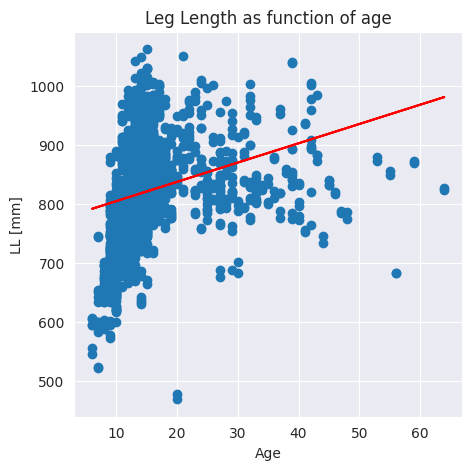

In [127]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X, Y)
ax.plot(X, reg.predict(X), 'r')
ax.set(title='Leg Length as function of age', xlabel='Age', ylabel='LL [mm]')
plt.show()

# Leg Length as function of sex

In [128]:
data = combined[['LL', 'Sex']].copy()
data = data.dropna()

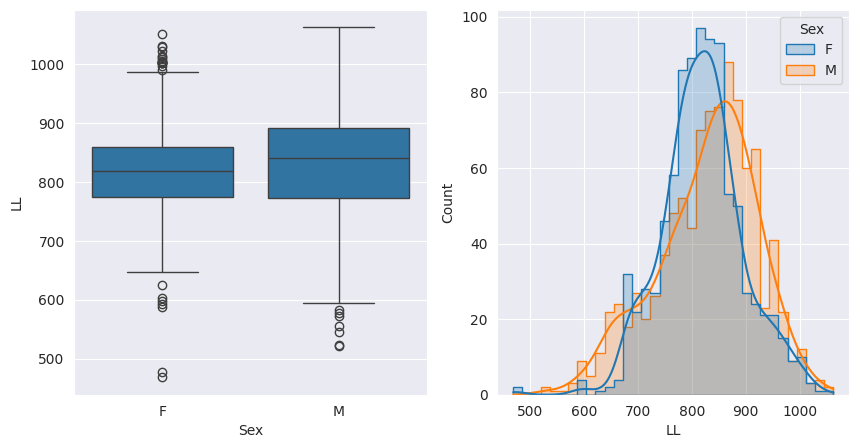

In [129]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.boxplot(x='Sex', y='LL', data=data, ax=ax[0])
sns.histplot(x='LL', hue='Sex', kde=True, element='step', data=data, ax=ax[1])
plt.show()

In [130]:
lb = LabelBinarizer()
lb.fit(data['Sex'])
labels = lb.transform(data['Sex'])
pd.DataFrame(data={'Sex': data['Sex'], 'Label': labels.T[0]})

Sex  Label
Patient  Side            
PA000291 right   F      0
         left    F      0
PA000464 right   F      0
         left    F      0
PA000654 right   F      0
...             ..    ...
PA001031 left    F      0
PA000807 right   F      0
         left    F      0
PA000227 right   M      1
         left    M      1

[1898 rows x 2 columns]

In [131]:
stats.pointbiserialr(labels.T[0], data['LL'].to_numpy())  # wtf numpy

SignificanceResult(statistic=0.053244060233633865, pvalue=0.02035438768252466)

**Interpretation:** Positive coefficient means LL is higher for males (encoded as 1)

## Normality testing

In [132]:
ll_male, ll_female = data[data['Sex'] == 'M']['LL'], data[data['Sex'] == 'F']['LL']

In [133]:
stats.shapiro(ll_male.to_numpy())

ShapiroResult(statistic=0.9802714298295409, pvalue=3.055097283420422e-10)

In [134]:
stats.shapiro(ll_female.to_numpy())

ShapiroResult(statistic=0.9887022815195998, pvalue=1.5899026983739825e-06)

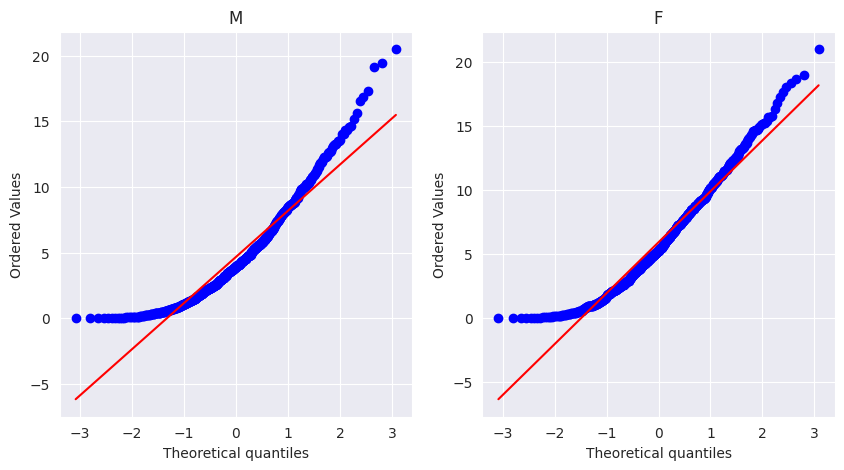

In [135]:

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
stats.probplot(kra_male.to_numpy(), plot=ax[0])
ax[0].set(title='M')
stats.probplot(kra_female.to_numpy(), plot=ax[1])
ax[1].set(title='F')
plt.show()

**Plots show data are not normally distributed**

**Can assume both to not have equal variance**

In [136]:
stats.mannwhitneyu(ll_male, ll_female, alternative='two-sided')

MannwhitneyuResult(statistic=499780.0, pvalue=2.8923806906205194e-05)

**-> There is a significant difference between male and female**

## Effect size

In [137]:
tmp1, tmp2 = ll_male.to_numpy(), ll_female.to_numpy()

In [138]:
%%R -i tmp1 -i tmp2
ll_male <- tmp1
ll_female <- tmp2

In [139]:
%%R
rb <- rank_biserial(ll_male, ll_female)
print(interpret(rb, rules='funder2019'))

r (rank biserial) |       95% CI | Interpretation
-------------------------------------------------
0.11              | [0.06, 0.16] |          small

- Interpretation rule: funder2019

# AT as function of other factors

## AT (Lee)

In [140]:
data = combined[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['AT (Lee)']
X = data[['AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [141]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [142]:
scaler = StandardScaler()
X_1 = scaler.fit_transform(X, Y)
X_1

array([[-0.23945804, -0.35452885,  0.42906131, -0.58711177, -0.32436831,
         0.36139297],
       [ 1.6582853 ,  1.25315821, -0.15267579, -0.19830473,  1.01511128,
         0.33102031],
       [-1.91280578, -1.0926079 , -1.06920309, -0.34075755,  0.08167337,
        -0.62754096],
       ...,
       [-1.34794821,  1.69335473,  0.90716221,  0.77944835, -1.294384  ,
        -0.07945715],
       [-1.5869405 , -1.33953258, -0.41228767, -0.85616153, -0.80829541,
         0.54231001],
       [-1.01992749, -1.25806294, -0.60709506,  0.02228192, -1.03145983,
         0.52971047]])

In [143]:
transformer = PowerTransformer(method='yeo-johnson')
X_2 = transformer.fit_transform(X, Y)
X_2

array([[-0.21807534, -0.26282312,  0.43036092, -0.59565506, -0.11409348,
         0.33135563],
       [ 1.6233676 ,  1.22233918, -0.15095612, -0.20893962,  1.04572883,
         0.2999545 ],
       [-1.98170195, -1.146681  , -1.069264  , -0.3510133 ,  0.30428335,
        -0.65530327],
       ...,
       [-1.35088647,  1.55302082,  0.90730488,  0.77714883, -1.80306319,
        -0.11760782],
       [-1.60802548, -1.48146421, -0.41075484, -0.86121985, -0.76124886,
         0.51983556],
       [-1.00789503, -1.36855526, -0.60586283,  0.01190288, -1.15917647,
         0.50662966]])

In [144]:
from sklearn.feature_selection import f_regression, r_regression

In [145]:
def pretty_print(x, y, var_names):
    f = f_regression(x, y)
    r = r_regression(x, y)
    table = pd.DataFrame(data = [r, f[0], f[1]], columns=var_names, index=pd.Index(['r value', 'f value', 'p value']))
    return table.T

In [146]:
pretty_print(X_1, Y, X.columns)

,r value,f value,p value
AT (Murphy),0.873833,3339.657278,0.000000e+00
CCD (actual),0.016923,0.296218,5.863807e-01
CCD (projected),-0.017975,0.334191,5.633275e-01
TT,0.158798,26.748716,2.781380e-07
KRA,0.268226,80.158258,1.571827e-18
LL,-0.335641,131.273815,1.069811e-28


In [147]:
pretty_print(X_2, Y, X.columns)

,r value,f value,p value
AT (Murphy),0.871807,3275.183067,9.387247e-323
CCD (actual),0.025341,0.664422,4.151907e-01
CCD (projected),-0.018106,0.339102,5.604750e-01
TT,0.160314,27.275234,2.132952e-07
KRA,0.266013,78.740988,3.059897e-18
LL,-0.330752,127.010624,7.219896e-28


In [148]:
reg_1, reg_2, reg_3 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['KRA'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
X_3 = data['TT'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)

LinearRegression()

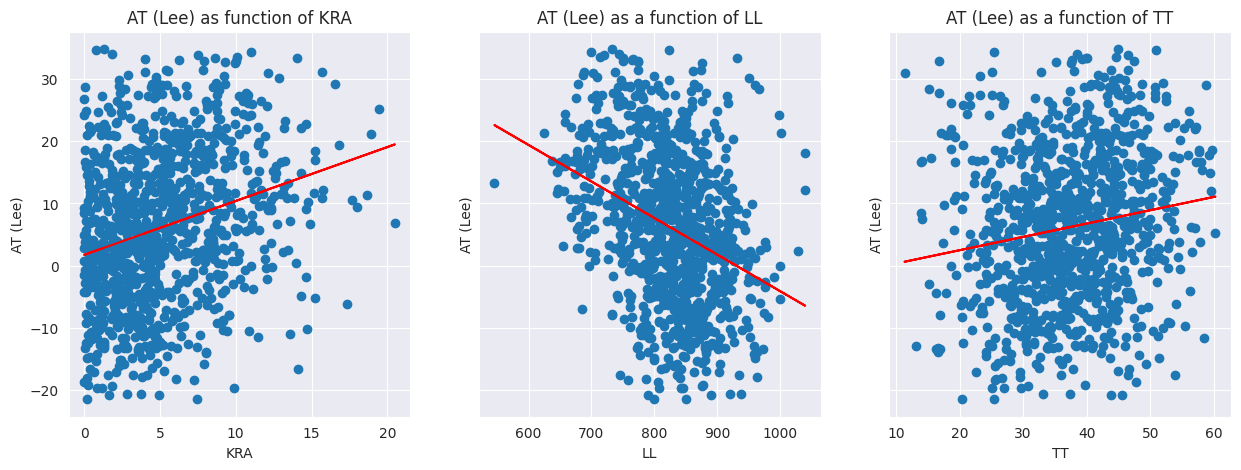

In [149]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='AT (Lee) as function of KRA', xlabel='KRA', ylabel='AT (Lee)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='AT (Lee) as a function of LL', xlabel='LL', ylabel='AT (Lee)')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='AT (Lee) as a function of TT', xlabel='TT', ylabel='AT (Lee)')
plt.show()

## AT (Murphy)

In [150]:
data = combined[['AT (Murphy)', 'AT (Lee)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['AT (Murphy)']
X = data[['AT (Lee)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [151]:
X = transformer.fit_transform(X, Y)

In [152]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.872973,3312.033182,0.000000e+00
CCD (actual),0.100297,10.507231,1.227056e-03
CCD (projected),-0.031708,1.040631,3.079133e-01
TT,0.156155,25.843623,4.392698e-07
KRA,0.238357,62.284382,7.541471e-15
LL,-0.237870,62.014822,8.580881e-15


In [153]:
reg_1, reg_2, reg_3, reg_4 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['KRA'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
X_3 = data['CCD (actual)'].to_numpy().reshape(-1, 1)
X_4 = data['TT'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)
reg_4.fit(X_4, Y)

LinearRegression()

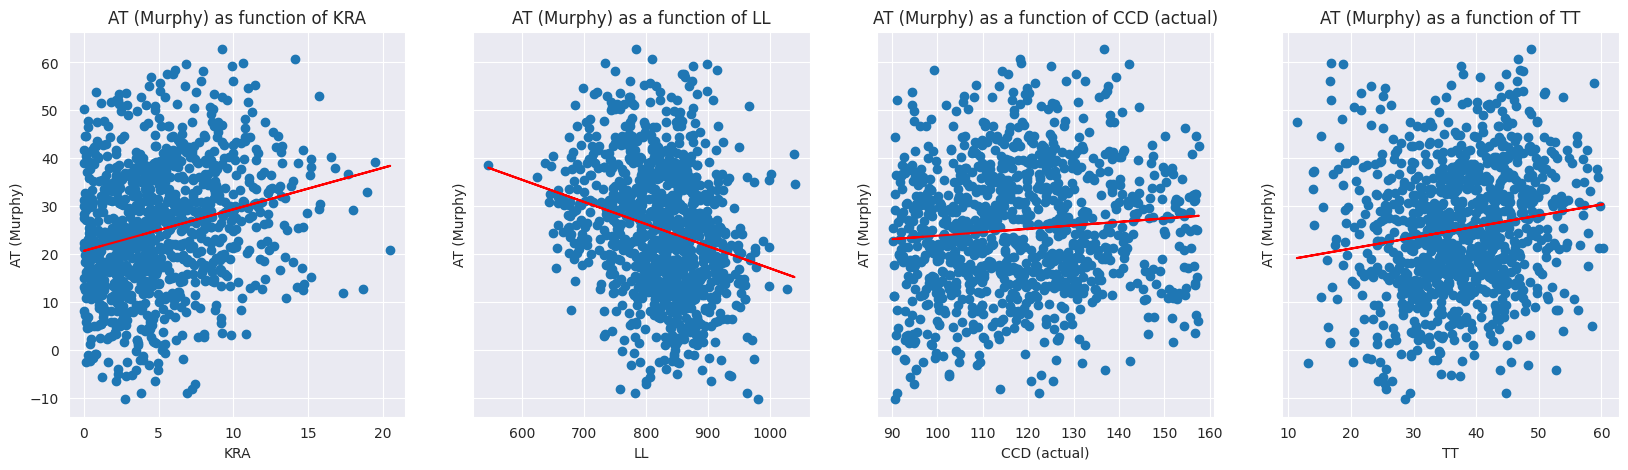

In [154]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='AT (Murphy) as function of KRA', xlabel='KRA', ylabel='AT (Murphy)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='AT (Murphy) as a function of LL', xlabel='LL', ylabel='AT (Murphy)')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='AT (Murphy) as a function of CCD (actual)', xlabel='CCD (actual)', ylabel='AT (Murphy)')
ax[3].scatter(X_4, Y)
ax[3].plot(X_4, reg_4.predict(X_4), 'r')
ax[3].set(title='AT (Murphy) as a function of TT', xlabel='TT', ylabel='AT (Murphy)')
plt.show()

# TT as function of other factors

In [155]:
data = combined[['TT', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['TT']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'KRA', 'LL']]

In [156]:
X = transformer.fit_transform(X, Y)

In [157]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.159878,27.123185,2.302812e-07
AT (Murphy),0.156705,26.030721,3.996427e-07
CCD (actual),-0.024999,0.646604,4.215144e-01
CCD (projected),-0.140513,20.826297,5.631940e-06
KRA,-0.038024,1.497115,2.213945e-01
LL,-0.007139,0.052702,8.184714e-01


In [158]:
reg_1, reg_2, reg_3 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_3 = data['CCD (projected)'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)

LinearRegression()

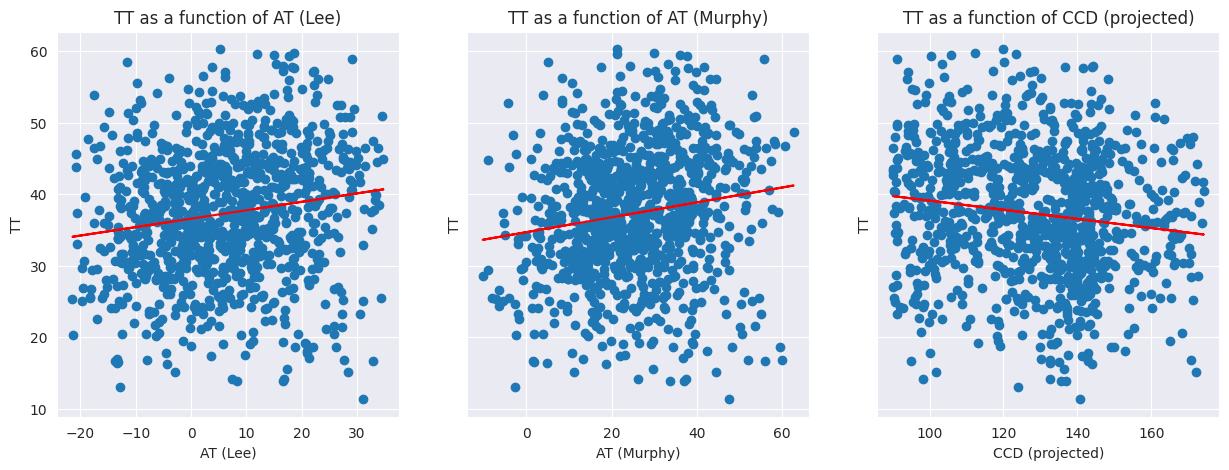

In [159]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='TT as a function of AT (Lee)', xlabel='AT (Lee)', ylabel='TT')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='TT as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='TT')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='TT as a function of CCD (projected)', xlabel='CCD (projected)', ylabel='TT')
plt.show()

# CCD as function of other factors

## CCD (actual)

In [160]:
data = combined[['CCD (actual)', 'AT (Lee)', 'AT (Murphy)', 'CCD (projected)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['CCD (actual)']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (projected)', 'TT', 'KRA', 'LL']]

In [161]:
X = transformer.fit_transform(X, Y)

In [162]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.019520,0.394139,5.302704e-01
AT (Murphy),0.091945,8.815822,3.055191e-03
CCD (projected),0.423029,225.368493,3.121840e-46
TT,-0.031700,1.040086,3.080401e-01
KRA,-0.038883,1.565671,2.111199e-01
LL,0.126268,16.752699,4.589836e-05


In [163]:
reg_1, reg_2 = linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_2 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)

LinearRegression()

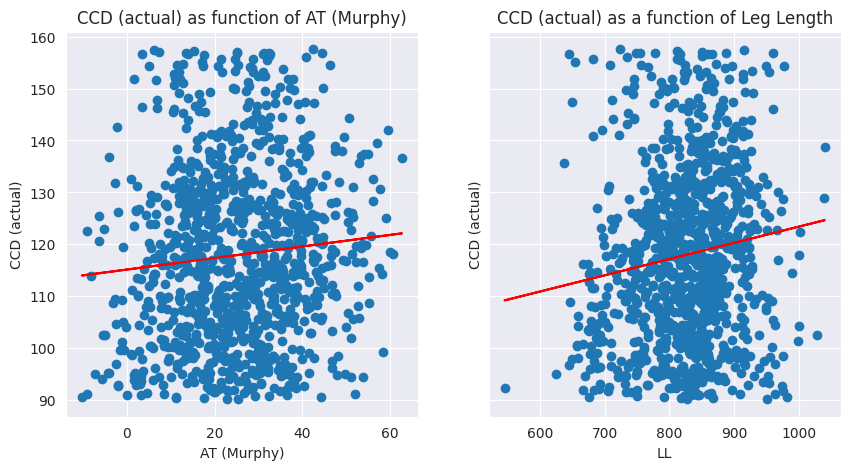

In [164]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='CCD (actual) as function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='CCD (actual)')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='CCD (actual) as a function of Leg Length', xlabel='LL', ylabel='CCD (actual)')
plt.show()

## CCD (projected)

In [165]:
data = combined[['CCD (projected)', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'TT', 'KRA', 'LL']].copy()
data = data.dropna()
Y = data['CCD (projected)']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'TT', 'KRA', 'LL']]

In [166]:
X = transformer.fit_transform(X, Y)

In [167]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),-0.018267,0.345134,5.570091e-01
AT (Murphy),-0.031902,1.053443,3.049556e-01
CCD (actual),0.375748,169.986743,4.394016e-36
TT,-0.141190,21.031624,5.070316e-06
KRA,-0.015881,0.260844,6.096502e-01
LL,-0.024910,0.642008,4.231688e-01


In [168]:
reg_1 = linear_model.LinearRegression()
X_1 = data['TT'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)

LinearRegression()

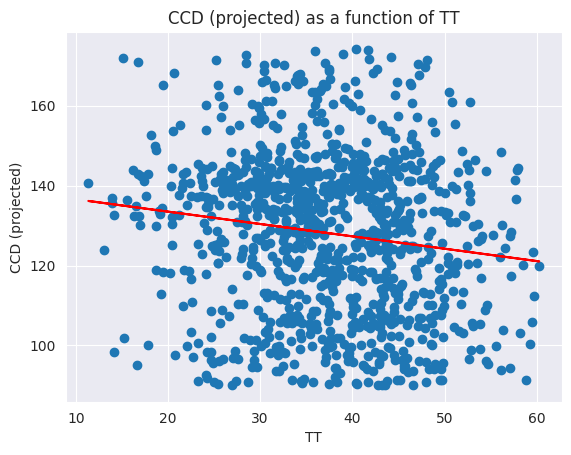

In [169]:
fig, ax = plt.subplots()
ax.scatter(X_1, Y)
ax.plot(X_1, reg_1.predict(X_1), 'r')
ax.set(title='CCD (projected) as a function of TT', xlabel='TT', ylabel='CCD (projected)')
plt.show()

# KRA as function of other factors

In [170]:
data = combined[['KRA', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'LL']].copy()
data = data.dropna()
Y = data['KRA']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'LL']]

In [171]:
X = transformer.fit_transform(X, Y)

In [172]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),0.267698,79.818792,1.843570e-18
AT (Murphy),0.242237,64.456053,2.668830e-15
CCD (actual),-0.017257,0.308032,5.790104e-01
CCD (projected),0.004377,0.019813,8.880878e-01
TT,-0.043293,1.941671,1.637866e-01
LL,-0.095940,9.605947,1.991903e-03


In [173]:
reg_1, reg_2, reg_3 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_3 = data['LL'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)

LinearRegression()

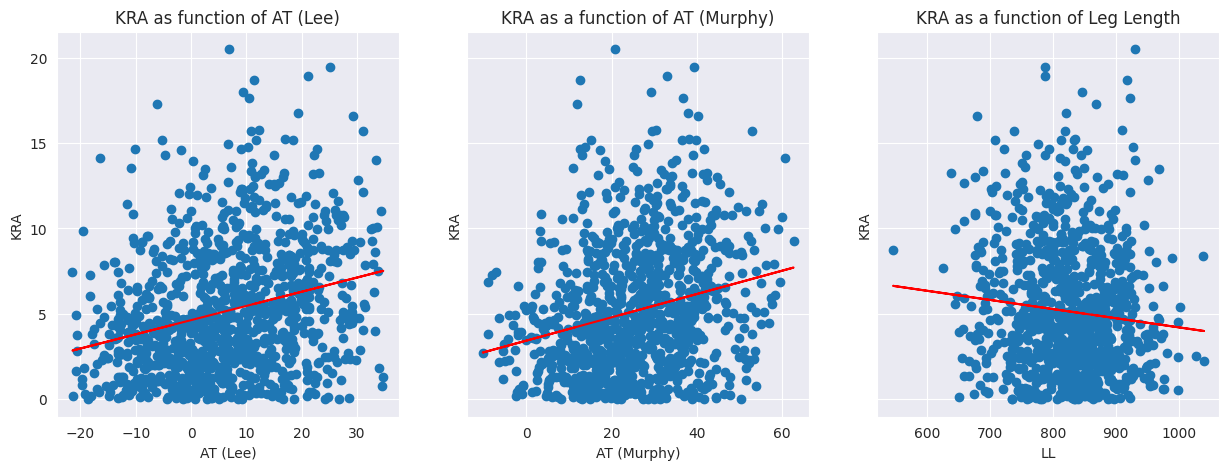

In [174]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='KRA as function of AT (Lee)', xlabel='AT (Lee)', ylabel='KRA')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='KRA as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='KRA')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='KRA as a function of Leg Length', xlabel='LL', ylabel='KRA')
plt.show()

# Leg Length as function of other factors

In [175]:
data = combined[['LL', 'AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA']].copy()
data = data.dropna()
Y = data['LL']
X = data[['AT (Lee)', 'AT (Murphy)', 'CCD (actual)', 'CCD (projected)', 'TT', 'KRA']]

In [176]:
X = transformer.fit_transform(X, Y)

In [177]:
pretty_print(X, Y, data.columns[1:])

,r value,f value,p value
AT (Lee),-0.333865,129.714678,2.148797e-28
AT (Murphy),-0.239532,62.937539,5.516376e-15
CCD (actual),0.133876,18.870252,1.536980e-05
CCD (projected),-0.028430,0.836430,3.606331e-01
TT,-0.008787,0.079838,7.775735e-01
KRA,-0.089564,8.361544,3.912696e-03


In [178]:
reg_1, reg_2, reg_3, reg_4 = linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression(), linear_model.LinearRegression()
X_1 = data['AT (Lee)'].to_numpy().reshape(-1, 1)
X_2 = data['AT (Murphy)'].to_numpy().reshape(-1, 1)
X_3 = data['KRA'].to_numpy().reshape(-1, 1)
X_4 = data['CCD (actual)'].to_numpy().reshape(-1, 1)
reg_1.fit(X_1, Y)
reg_2.fit(X_2, Y)
reg_3.fit(X_3, Y)
reg_4.fit(X_4, Y)

LinearRegression()

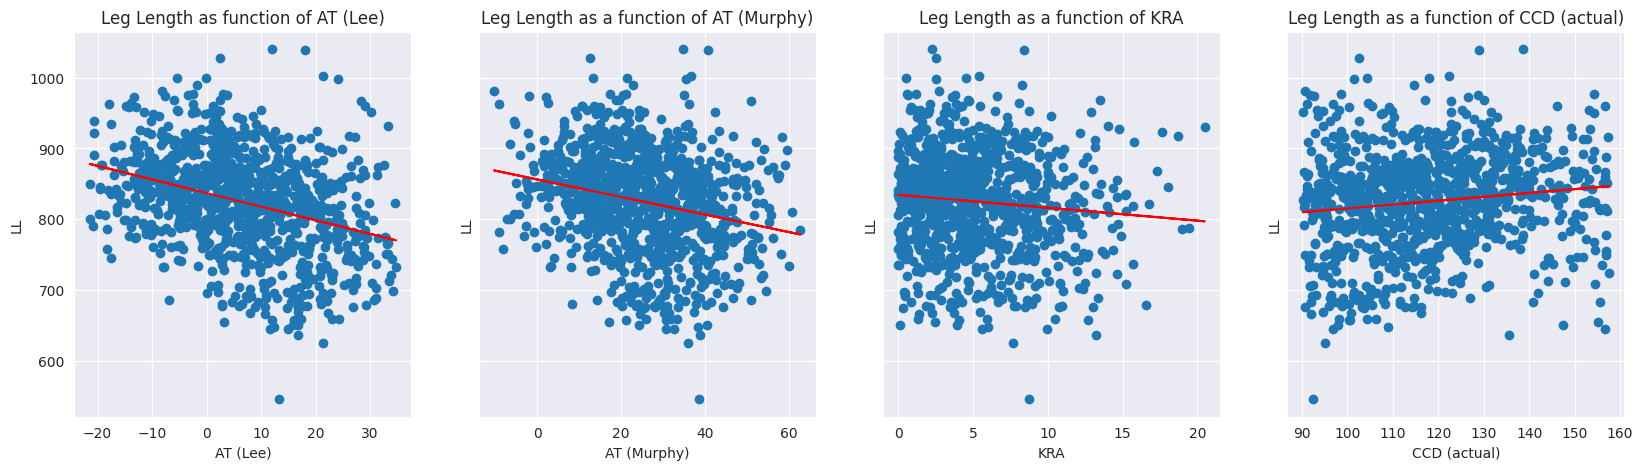

In [179]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 5), sharex=False, sharey=True)
ax[0].scatter(X_1, Y)
ax[0].plot(X_1, reg_1.predict(X_1), 'r')
ax[0].set(title='Leg Length as function of AT (Lee)', xlabel='AT (Lee)', ylabel='LL')
ax[1].scatter(X_2, Y)
ax[1].plot(X_2, reg_2.predict(X_2), 'r')
ax[1].set(title='Leg Length as a function of AT (Murphy)', xlabel='AT (Murphy)', ylabel='LL')
ax[2].scatter(X_3, Y)
ax[2].plot(X_3, reg_3.predict(X_3), 'r')
ax[2].set(title='Leg Length as a function of KRA', xlabel='KRA', ylabel='LL')
ax[3].scatter(X_4, Y)
ax[3].plot(X_4, reg_4.predict(X_4), 'r')
ax[3].set(title='Leg Length as a function of CCD (actual)', xlabel='CCD (actual)', ylabel='LL')
plt.show()